#### 11/06/24
---
---
# <center> **Random Forest**
---

## <center> **Projetos em Ciência de Dados**

#### <center> **Pós-Graduação - Instituto Mauá de Tecnologia**

#### <center> **VCP e Lucas Buk**
---
---


# **Introdução**

De forma geral, podemos combinar diversos preditores ou regressores buscando um melhor desempenho do sistema criado. deve-se observar que podemos obter um resultado melhor quando analisado sob determinada métrica mas com uma interpretação não tão direta quando utilziamos um úncio sistema. É uma decisão que merece ser analisada a luz da aplicação.

Em linhas gerais, vamos abordar:

1.   O conceito de ensemble
2.   Majority voting ou Hard voting
3.   Weighted Majority Vote
4.   Soft Voting
5.   Stacking machine learning models
6.   Bagging

**Sistemas de votação e sua modelagem**

Problema geral:

Desejamos predizer uma variável aleatória $y \in \{\pm1\}$ a partir de um um cojunto de variáveis aleatórias de entrada $X_i \in \{\pm 1\}$ obtida para cada sistema especilista (em $n$).

Cada sistema especilista tem uma capacidade de predição de sua respectiva componente $X_i$ com um nível $p \in (0,1)$, trata-se de probabilidade de que a predição esteja correta: $P(X_i = y) = p_i$

Geralmente temos duas hipóteses simplificadoras:

1.   A variáveis aletaórias $\{ X_i: i \in [n]\}$ são mutuamente independentes quando condicionadas a verdade de $y$.
2.   O sistema é balanceado: $P(y = +1) = P(y =-1) = \dfrac{1}{2}$.






**Weighted Majority Vote**

Supondo dois classificadores $C_1$ e $C_2$, cada um obtém uma probabildiade associada a estimativa em curso $p_{ij}$ : i-ésima categoria para o j-ésimo classificador, neste exemplo $(2,2)$. Os valores são ponderados por pesos: $w_1$ e $w_2$ correspondente ao Classificador.

Em linhas gerais, o "score" final pode ser calculado para o casos $(2,2)$:

$\begin{equation}
  Score(X_1) = w_1 p_{11} + w_2 p_{12} \\
  Score(X_2) = w_1 (1 - p_{11}) + w_2 (1- p_{12}) \\
  \end{equation} $

  onde $X_2$ é a negativa de $X_1$.

  Neste caso escolhe-se o valor máximo de Score para identificar a categoria mais provável.

# **Bibliotecas**

In [ ]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seed = 7 # semente para o random_state

# **Funções**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(model, X, y, format='.3f'):
    """Função para exibir a matriz de confusão"""

    ConfusionMatrixDisplay.from_estimator(model, X, y,
                                          values_format=format,
                                          cmap='Blues',
                                          normalize='true')
    plt.show()

# **Dados**

**Diabetes**
1. Number of times pregnant
2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test
3. Diastolic blood pressure (mm Hg)
4. Triceps skin fold thickness (mm)
5. 2-Hour serum insulin (mu U/ml)
6. Body mass index (weight in kg/(height in m)^2)
7. Diabetes pedigree function
8. Age (years)
9. Diag (0 or 1)

In [ ]:
!gdown 1byAE7s0IzBT2gaEb57ZnicmSb7yJnTbk --quiet

In [ ]:
# Leitura dos dados
df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head(3)

In [ ]:
df.isna().sum()

# **Pré-processamento**

In [ ]:
X = df.drop('Diag', axis=1).copy()
y = df['Diag'].copy()

In [ ]:
X

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=seed)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

# **Voting**

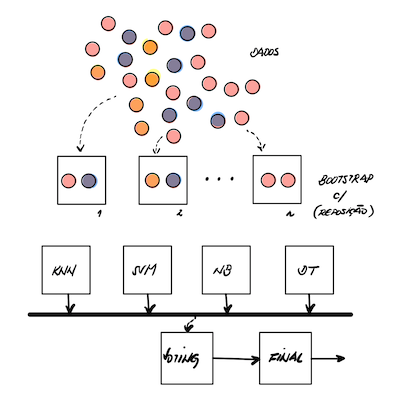

In [ ]:
X_train_peq = X_train[['Glicose', 'Idade']]
X_test_peq = X_test[['Glicose', 'Idade']]

In [ ]:
X_train_peq

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_peq = ss.fit_transform(X_train_peq)
X_test_peq = ss.transform(X_test_peq)

In [ ]:
X_train_peq

In [ ]:
# Definição dos modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Árvore
dt = DecisionTreeClassifier(max_depth=4,
                            criterion='entropy',
                            random_state=seed)
# KNN
knn = KNeighborsClassifier(n_neighbors=7)

# SVM
svm = SVC(kernel='rbf', gamma=0.1,
          probability=True, random_state=seed)

dt.fit(X_train_peq, y_train)
knn.fit(X_train_peq, y_train)
svm.fit(X_train_peq, y_train)

In [ ]:
from sklearn.ensemble import VotingClassifier

clf = VotingClassifier(estimators=[('Decision Tree', dt),
                                   ('KNN', knn),
                                   ('SVM', svm)],
                       voting='soft')

clf.fit(X_train_peq, y_train)

In [ ]:
from itertools import product

####### Regiões de convergência
# Criação de uma malha para predição do classificador em estudo
# Definindo os limites mínimos e máximos para as variáveis de entrada
x_min, x_max = X_train_peq[:, 0].min() - 1, X_train_peq[:, 0].max() + 1
y_min, y_max = X_train_peq[:, 1].min() - 1, X_train_peq[:, 1].max() + 1

# Criando uma grade de valores de x e y para o espaço de entrada
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Configuração do gráfico com subplots
f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(10, 8))

# Para cada classificador, faz uma predição e compara
for idx, clf, tt in zip(product([0, 1], [0, 1]),
                        [dt, knn, svm, clf],
                        ['Decision Tree (depth=4)', 'KNN (k=7)',
                         'Kernel SVM', 'Soft Voting']):

    # Predizendo os valores da grade criada
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotando as regiões de decisão
    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.4)
    # Plotando os pontos de treino
    axarr[idx[0], idx[1]].scatter(X_train_peq[:, 0], X_train_peq[:, 1], c=y_train,
                                  s=20, edgecolor='k')
    # Definindo o título do subplot
    axarr[idx[0], idx[1]].set_title(tt)

# Exibindo o gráfico
plt.show()

In [ ]:
clf = VotingClassifier(estimators=[('Decision Tree', dt),
                                   ('KNN', knn),
                                   ('SVM', svm)],
                       voting='hard',
                       weights=[1.25, 1, 1])

clf.fit(X_train_peq, y_train)

In [ ]:
from itertools import product

####### Regiões de convergência
# Criação de uma malha para predição do classificador em estudo
# Definindo os limites mínimos e máximos para as variáveis de entrada
x_min, x_max = X_train_peq[:, 0].min() - 1, X_train_peq[:, 0].max() + 1
y_min, y_max = X_train_peq[:, 1].min() - 1, X_train_peq[:, 1].max() + 1

# Criando uma grade de valores de x e y para o espaço de entrada
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Configuração do gráfico com subplots
f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(10, 8))

# Para cada classificador, faz uma predição e compara
for idx, clf, tt in zip(product([0, 1], [0, 1]),
                        [dt, knn, svm, clf],
                        ['Decision Tree (depth=4)', 'KNN (k=7)',
                         'Kernel SVM', 'Hard Voting']):

    # Predizendo os valores da grade criada
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotando as regiões de decisão
    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.4)
    # Plotando os pontos de treino
    axarr[idx[0], idx[1]].scatter(X_train_peq[:, 0], X_train_peq[:, 1], c=y_train,
                                  s=20, edgecolor='k')
    # Definindo o título do subplot
    axarr[idx[0], idx[1]].set_title(tt)

# Exibindo o gráfico
plt.show()

# **Ensemble**

**Soft Voting**

Para o caso do soft voting ponderado, consideramos sua probabilidade condicional:

$\hat{y} = argmax_i \; \;[p(C_0 \vert X),p(C_1 \vert X), \ldots, p(C_N \vert X)]$

In [ ]:
# Normalização dos dados completos
ss = StandardScaler()
X_train_norm = ss.fit_transform(X_train)
X_test_norm = ss.transform(X_test)

In [ ]:
X_train_norm

In [ ]:
# Modelos
dt = DecisionTreeClassifier(max_depth=4,
                            criterion='entropy',
                            random_state=seed)

knn = KNeighborsClassifier(n_neighbors=7)

svm = SVC(random_state=seed, kernel='rbf',
          gamma=0.1, probability=True)

In [ ]:
from sklearn.metrics import accuracy_score

# Treino dos classificadores
dt.fit(X_train_norm, y_train)
knn.fit(X_train_norm, y_train)
svm.fit(X_train_norm, y_train)

# Predição dos classificadores
predicao_dt = dt.predict(X_test_norm)
predicao_knn = knn.predict(X_test_norm)
predicao_svm = svm.predict(X_test_norm)

pred_final = np.round((predicao_dt+predicao_knn+predicao_svm)/3)

accuracy_score(y_test, pred_final)

**Majority voting ou Hard voting**

No caso da votação por maioria, trata-se de indentificar qual a classe com maior frequência entre os diversos classificadores. Muitas vezes se opta por um critério de que o resulatdo tem que ser superior a $50 \%$ dos votos. Ou pode ser maioria simples.

$\hat{y} = Moda \{C_1(X), C_2(X), \ldots , C_N \}$

In [ ]:
# Criando os calssificadores
dt = DecisionTreeClassifier(max_depth=4,
                            criterion='entropy',
                            random_state=seed)

knn = KNeighborsClassifier(n_neighbors=7)

svm = SVC(random_state=seed, kernel='rbf', gamma=0.1, probability=True)
clf = VotingClassifier(estimators=[('dt', dt), ('knn', knn),
                                   ('svc', svm)],
                       voting='hard', weights=[2, 1, 2])

# Treino os classificadores
dt.fit(X_train_norm, y_train)
knn.fit(X_train_norm, y_train)
svm.fit(X_train_norm, y_train)
clf.fit(X_train_norm, y_train)

# Predição do ensemble
predicao_final = clf.predict(X_test_norm)

# Métrica
acuracia = accuracy_score(y_test, predicao_final)
print(acuracia)

# **Bagging**

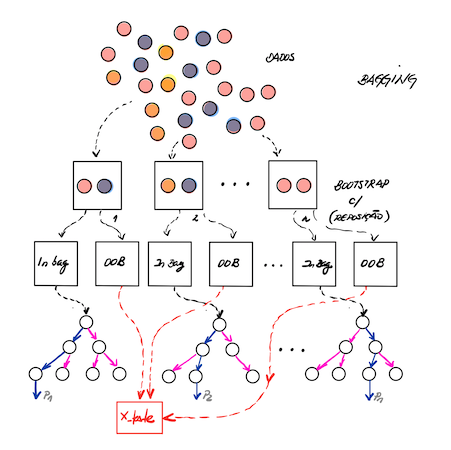

**Validação cruzada**

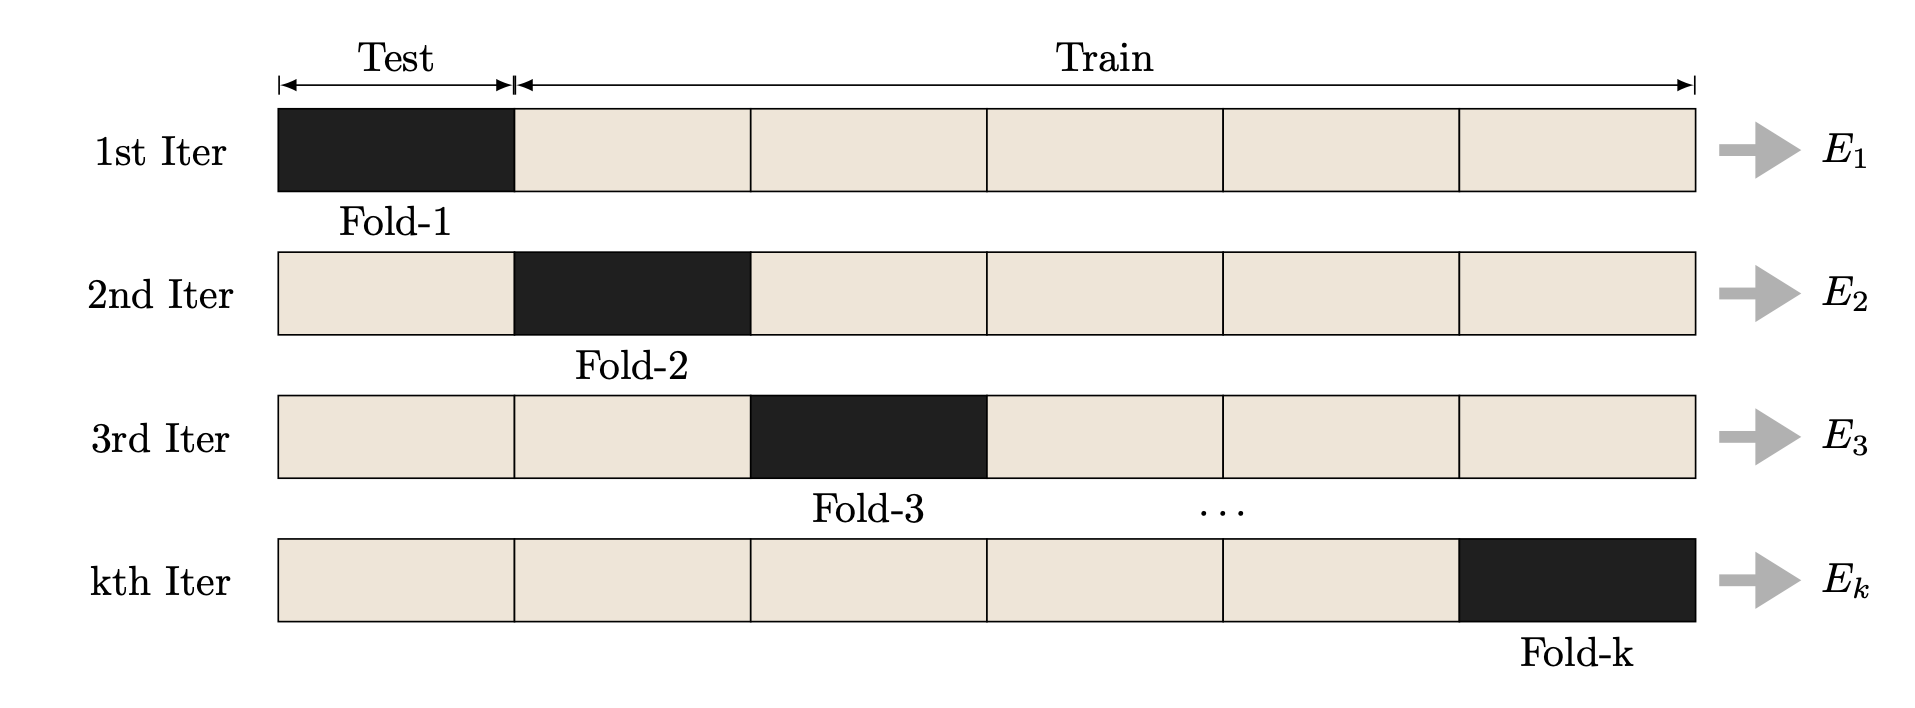

In [ ]:
from sklearn.ensemble import BaggingClassifier

SVM_clf = svm

svm_bagging = BaggingClassifier(SVM_clf, n_estimators=30, random_state=seed)
svm_bagging.fit(X_train_norm, y_train)

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Função para avaliar um modelo utilizando validação cruzada com bagging
def evaluate_model_bagging(model, X, y):

    # Configura a estratégia de validação cruzada com K-Folds
    k_folds = KFold(n_splits=10, random_state=seed, shuffle=True)

    # Avalia o modelo utilizando validação cruzada
    results = cross_val_score(model, X, y, scoring='accuracy', cv=k_folds)

    # Imprime a média dos resultados de acurácia
    print(results.mean())

In [ ]:
# Resultados para os modelos com validação cruzada
# evaluate_model_bagging(KNN_bagging_model, X_train_norm, y_train)
# evaluate_model_bagging(DT_bagging_model, X_train_norm, y_train)
evaluate_model_bagging(svm_bagging, X_train_norm, y_train)

In [ ]:
evaluate_model_bagging(svm, X_train_norm, y_train)

# **Model Selection**

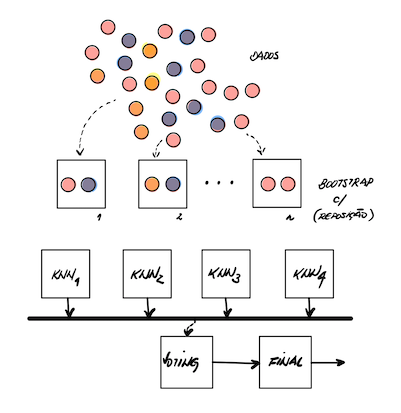

**Ensemble KNN**

In [ ]:
def get_voting_KNN():
	# Lista dos modelos de base para a formação do ensemble
	models = list()
	models.append(('knn5', KNeighborsClassifier(n_neighbors=5)))
	models.append(('knn7', KNeighborsClassifier(n_neighbors=7)))
	models.append(('knn9', KNeighborsClassifier(n_neighbors=9)))
	models.append(('knn11', KNeighborsClassifier(n_neighbors=11)))
	models.append(('knn13', KNeighborsClassifier(n_neighbors=13)))

	# Define o tipo de votação de ensemble
	ensemble = VotingClassifier(estimators=models, voting='soft')
	return ensemble

# Dicionário de modelos que serão utilizados no cálculo
def get_models_KNN():

	models = dict()
	models['knn5'] = KNeighborsClassifier(n_neighbors=5)
	models['knn7'] = KNeighborsClassifier(n_neighbors=7)
	models['knn9'] = KNeighborsClassifier(n_neighbors=9)
	models['knn11'] = KNeighborsClassifier(n_neighbors=11)
	models['knn13'] = KNeighborsClassifier(n_neighbors=13)
	models['soft_voting'] = get_voting_KNN()

	return models

In [ ]:
# Avalia um modelo utilizando validação cruzada
from sklearn.model_selection import RepeatedStratifiedKFold

# Função para avaliar um modelo utilizando validação cruzada
def evaluate_model(model, X, y):

    # Configura a estratégia de validação cruzada com K-Folds estratificados repetidos
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=seed)

    # Avalia o modelo utilizando validação cruzada
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)

    # Retorna os scores de acurácia obtidos em cada iteração da validação cruzada
    return scores

In [ ]:
models_KNN = get_models_KNN()
models_KNN

In [ ]:
# Avalia o desempenho dos modelos e armazena os resultados para uma determinada métrica
results, names = list(), list()

# Para cada modelo na lista de modelos
for name, model in models_KNN.items():
    # Avalia o modelo e obtém os scores de desempenho
    scores = evaluate_model(model, X_train_norm, y_train)

    # Armazena os resultados e os nomes dos modelos
    results.append(scores)
    names.append(name)

    # Imprime o nome do modelo e sua média e desvio padrão dos scores de desempenho
    print(f'> {name} {np.mean(scores):.3f} ({np.std(scores):.3f})')

In [ ]:
# Boxplot acerca do desempenho de cada modelo
plt.boxplot(results, labels=names, showmeans=True)
plt.show()

# **Random Forest**

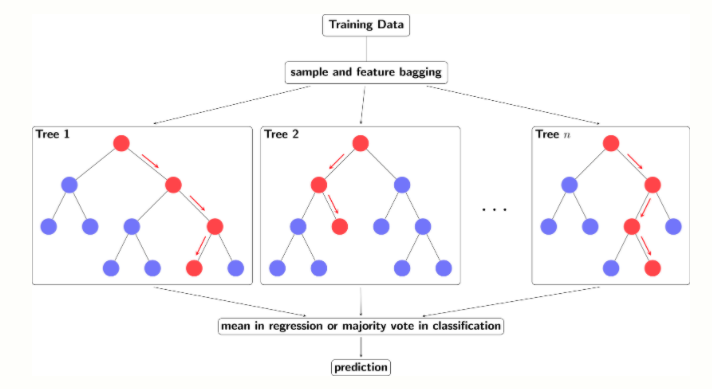

In [ ]:
# Quantidade em cada classe
y_train.value_counts()

In [ ]:
X_train_norm

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(random_state=seed,
                                 criterion='entropy')

rf_base.fit(X_train_norm, y_train)

In [ ]:
plot_cm(rf_base, X_test_norm, y_test)

In [ ]:
# Métricas do modelo base
from sklearn.metrics import accuracy_score, balanced_accuracy_score

print(f'Acurácia: {accuracy_score(y_test, rf_base.predict(X_test_norm)):.4f}')
print(f'Acurácia p/ classes desbalanceadas: {balanced_accuracy_score(y_test, rf_base.predict(X_test_norm)):.4f}')

## **Melhores hiperparâmetros**

A estratégia utilizada será buscar um hiperparâmetro do modelo por vez, com eles serão definidos os parâmetros seguintes.

**Função de validação cruzada**

In [ ]:
# Avalia um modelo utilizando validação cruzada estratificada
from sklearn.model_selection import StratifiedKFold

def evaluate_model(model, X, y):
    # Define a estratégia de validação cruzada estratificada
    cv = StratifiedKFold(n_splits=10, random_state=seed, shuffle=True)

    # Calcula os scores de desempenho do modelo utilizando validação cruzada
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv)

    return scores

**max_depth:** profundidade máxima da árvore.

In [ ]:
# Cria diversos modelos variando a profundidade
def get_models():
    # Dicionário para armazenar os modelos
    models = dict()
    # Profundidades a serem testadas
    depths = [i for i in range(3, 12)] + [None]
    # Itera sobre as profundidades
    for n in depths:
        # Cria um modelo de Random Forest para cada profundidade
        models[str(n)] = RandomForestClassifier(max_depth=n,
                                                 criterion='entropy',
                                                 random_state=seed)
    return models


# Obtém os modelos
models = get_models()

# Lista para armazenar os resultados e nomes dos modelos
results, names = list(), list()

# Avalia o desempenho de cada modelo
for name, model in models.items():
    # Avalia o desempenho do modelo utilizando validação cruzada
    scores = evaluate_model(model, X_train_norm, y_train)
    results.append(scores)
    names.append(name)
    # Exibe os resultados numéricos
    print(f'> {name}: {np.mean(scores):.3f} ({np.std(scores):.3f})')

# Cria um boxplot comparativo dos resultados
plt.boxplot(results, labels=names, showmeans=True)
plt.show()

**n_estimators:** número de árvores utilizadas na predição.

In [ ]:
# Cria diversos modelos variando o número de estimadores
def get_models():
    # Dicionário para armazenar os modelos
    models = dict()
    # Número de estimadores a serem testados
    n_trees = [10, 50, 80, 100, 150, 200]
    # Itera sobre o número de estimadores
    for n in n_trees:
        # Cria um modelo de Random Forest para cada número de estimadores
        models[str(n)] = RandomForestClassifier(n_estimators=n,
                                                 max_depth=4,
                                                 criterion='entropy',
                                                 random_state=seed)
    return models


# Obtém os modelos
models = get_models()

# Lista para armazenar os resultados e nomes dos modelos
results, names = list(), list()

# Avalia o desempenho de cada modelo
for name, model in models.items():
    # Avalia o desempenho do modelo utilizando validação cruzada
    scores = evaluate_model(model, X_train_norm, y_train)
    results.append(scores)
    names.append(name)
    # Exibe os resultados numéricos
    print(f'> {name}: {np.mean(scores):.3f} ({np.std(scores):.3f})')

# Cria um boxplot comparativo dos resultados
plt.boxplot(results, labels=names, showmeans=True)
plt.show()

**Matriz de confusão do modelo base**

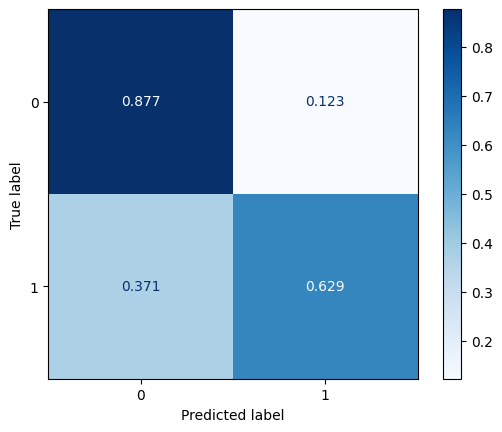

In [ ]:
rf = RandomForestClassifier(max_depth=4,
                            n_estimators=80,
                            criterion='entropy',
                            random_state=seed,
                            class_weight={0: 1, 1:1.55})

rf.fit(X_train_norm, y_train)

In [ ]:
plot_cm(rf, X_test_norm, y_test)

In [ ]:
print('Modelo base:')
print(f'    Acurácia: {accuracy_score(y_test, rf_base.predict(X_test_norm)):.4f}')
print(f'    Acurácia p/ classes desbalanceadas: {balanced_accuracy_score(y_test, rf_base.predict(X_test_norm)):.4f}')

print('\nModelo com os hiperparâmetros escolhidos:')
print(f'    Acurácia: {accuracy_score(y_test, rf.predict(X_test_norm)):.4f}')
print(f'    Acurácia p/ classes desbalanceadas: {balanced_accuracy_score(y_test, rf.predict(X_test_norm)):.4f}')

In [ ]:
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(8).plot(kind='barh', figsize=(7, 7))
plt.show()

In [ ]:
# Plot da árvore
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(rf[12], out_file=dot_data, filled=True,
                rounded=True, special_characters=True,
                feature_names=X_train.columns, max_depth=4,
                class_names=['0','1'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

# **Extra**

1. Usar o modelo **RandomForest** com os dados do Vinho (https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) da aula passada, seguindo as mesmas etapas
2. Realizar a escolha de pelo menos dois hiperparâmetros do modelo

Input variables (based on physicochemical tests):

* fixed acidity

* volatile acidity

* citric acid

* residual sugar

* chlorides

* free sulfur dioxide

* total sulfur dioxide

* density

* pH

* sulphates

* alcohol

Output variable (based on sensory data):

* quality (score between 0 and 10)

Sugestões de etapas:


1.   Ler os dados e criação do Label (Maior que 5 -> vinho bom)
2.   Análise do dataset (Valores faltantes, pairplot, matriz de correlação, ...)
3.   Divisão dos dados em treino e teste
4.   Pré-processamento
5.   Treinamento do modelo RandomForest
6.   Busca de pelo menos dois hiperparâmetros para o modelo
7.   Validação do modelo
8.   Exibição das features mais importantes e de uma parte de uma das árvores



**1. Ler os dados**

In [ ]:
!gdown 1ttOCd6VQH85CfdRvGXqt4UI3pjF73vJl --quiet

In [ ]:
df_redw = pd.read_csv('winequality-red.csv', sep=';') # sep = separador do csv

print(df_redw.shape)
df_redw.head(3)

# **Referências**

**Ensemble:** https://didatica.tech/metodos-ensemble/

**Voting Classifier:** https://www.geeksforgeeks.org/ml-voting-classifier-using-sklearn/

**Bagging Classifier:** https://www.geeksforgeeks.org/ml-bagging-classifier/

**Random Forest Classifier:** https://builtin.com/data-science/random-forest-algorithm

**Bagging and Random Forest Ensemble Algorithms for Machine Learning:** https://machinelearningmastery.com/bagging-and-random-forest-ensemble-algorithms-for-machine-learning/

**Métricas e validação cruzada:** https://medium.com/@jvsavietto6/machine-learning-m%C3%A9tricas-valida%C3%A7%C3%A3o-cruzada-bias-e-vari%C3%A2ncia-380513d97c95

**Cross-validation scikit-learn:** https://scikit-learn.org/stable/modules/cross_validation.html

**StratifiedKFold:** http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html